In [1]:
# ============================================================
# Notebook setup
# ============================================================

%load_ext autoreload
%autoreload 2

# Control figure size
figsize=(14, 4)

from util import util
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sn
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
import xgboost
from sklearn.inspection import permutation_importance
import shap
import pickle
import os

# Generate synthetic data
data, name_map = util.generate_data(size=500, seed=42)
num_cols = [c for c in data.columns[:-1] if len(data[c].unique()) > 2]
cat_cols = [c for c in data.columns[:-1] if len(data[c].unique()) == 2]

# Data pre-processing
X, y = data[data.columns[:-1]].copy(), data[data.columns[-1]].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Train a GBT model
base_est = xgboost.XGBClassifier(tree_method='hist', importance_type='total_gain')
param_grid={'max_depth': [2, 3, 4], 'n_estimators': list(range(20, 41, 5)), 'reg_lambda': np.linspace(0, 500, 6)}
gscv = GridSearchCV(base_est, param_grid=param_grid)
gscv.fit(X, y)
xbm, xbm_params = gscv.best_estimator_, gscv.best_params_

/Users/michelelombardi/Library/Caches/pypoetry/virtualenvs/06-at-RVmPecHn-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Additive Feature Attribution

## What we Gained, What we Lost

**When we switched from Logistic Regression to GBTs we gained a lot**

* A reliable proxy model
* A well defined and transparent feature importance definition
* Sparse and reliable importance scores

**However, we also lost something:**

With Linear Regression, we used to be able to:

* Identify the _direction_ of the correlation (through the coefficient sign)
* ...And explain _individual examples_, by looking at the difference:

$$
\theta^T x - \mathbb{E}_{x^\prime \in P(X)} \left[ \theta^T x^\prime \right]
$$

which is the difference between the score of the example and the average score of the dataset. This difference can be decomposed into the contribution of each feature, which is given by $\theta_i (x_i - \mathbb{E}_{x^\prime \in P(X)} [x_i^\prime])$. This allows us to understand how much each feature contributes to the prediction for that specific example, and whether it pushes the prediction higher or lower compared to the average. Why is that? Because of the linearity of the model, which allows us to decompose the prediction into a sum of contributions from each feature. In contrast, with non-linear models like GBTs, the relationship between features and predictions is more complex and cannot be easily decomposed in this way, making it harder to explain individual predictions.

## Local Interpretability: Explaining Individual Examples

Why did the model output this value for this specific input?
- Not: “Which features are important on average?”

but:

- “How did each feature contribute to this particular prediction?”

**Let's look again at the last equation:**

$$
\theta^T x - \mathbb{E}_{x^\prime \in P(X)} \left[ \theta^T x^\prime \right]
$$

* Assuming $P(X)$ is approximated by using a sample...
* ...Then $\mathbb{E}_{x^\prime \in P(X)} \left[ \theta^T x^\prime \right]$ is just the average prediction on the data

I.e. it is the prediction we could make _without access to any input value_

**Therefore, the difference above represents the gap between:**

* ...What we can predict given all information on one example
* ...And what we can predict with no such information

It's the collective _value of all available information_

## Explaining Individual Examples

**Due to linearity, the formula can be rewritten as:**

$$\begin{align}
\theta^T x - \mathbb{E}_{x^\prime \in P(X)} \left[ \theta^T x^\prime \right] & = \theta^T (x - \mathbb{E}_{x^\prime \in P(X)}[x^\prime]) \\
& = \sum_{j = 1}^n \theta_j (x_{j} - \mathbb{E}_{x_j^\prime \in P(X_j)}[x_j^\prime])
\end{align}$$

**What does this formula represent?**

The difference between:
* The prediction for a specific example: $\theta^T x$
* The average prediction across the dataset: $\mathbb{E}_{x^\prime \in P(X)} \left[ \theta^T x^\prime \right]$

This difference tells us how much this particular example's prediction deviates from the typical case.

**Why is this useful?**

Because of linearity, we can decompose this difference into individual feature contributions. Each feature's impact is:

$$\phi_{j}(x) = \theta_j (x_{j} - \mathbb{E}_{x_j^\prime \in P(X_j)}[x_j^\prime])$$

This is the _effect_ of attribute $j$ for the example $x$, which:
* Shows whether the feature value pushes the prediction higher or lower (sign of $\phi_j$)
* Quantifies by how much it deviates from average behavior (magnitude of $\phi_j$)
* Allows us to understand exactly which features were responsible for this specific prediction

**Can we generalize this process to non-linear models?**

## Additive Feature Attribution

**Given an example $x$, we can try to build an additive attribution model:**

$$
g(z, x) = \phi_0 + \sum_{j = 1}^n \phi_{j}(x) z_j \quad\text{with: } z_{j} \in \{0, 1\}
$$

* Where $z_j$ is called a _simplified input_
* ...And represents the fact that the $j$-th attribute is known or unknown

We are building a simple surrogate model. That model is linear, and it operates on “feature present / absent” variables. This is not the original model — it’s an explanation of it.

**Intuitively, we build a linear explaination for the model local behavior**

* Several ML explainability approaches can be seen as attempts at this
* ...Most notably the original LIME method

# SHAP: From Game Theory to Machine Learning

The core idea of **SHAP (SHapley Additive exPlanations)** is derived from **Cooperative Game Theory**. Imagine a group of people (a **coalition**) cooperating in a game, such as a Kaggle competition. After the game, the team receives a payout (e.g., $10,000). The central question is: *How is that money distributed fairly among members who contributed differently?*



In the context of Machine Learning:
* **The Players:** Individual input features (e.g., Age, BMI, Blood Pressure).
* **The Game:** The machine learning model $\hat{f}$.
* **The Payout:** The actual model prediction for a specific data point.

---

## A possible solution: _marginalizing_ over all subset of remaining features

To find the true contribution of a feature, we must consider its **marginal contribution**. Because features interact (e.g., a "Deep Learning Expert" and a "Domain Expert" might only provide high value when working together), we calculate how the prediction changes when a feature is added to every possible subset of other features.

Let $\mathcal{X}$ be the set of all input features; then the **Shapley Value** $\phi_{j}(x)$ for feature $j$ is:

$$
\phi_{j}(x) = \sum_{\mathcal{M} \subset \mathcal{X} \setminus \{j\}}
    \frac{|\mathcal{M}|! (n - |\mathcal{M}| - 1)!}{n!} (\hat{f}(x_{\mathcal{M} \cup \{j\}}) - \hat{f}(x_{\mathcal{M}}))
$$

where $n$ is the total number of features, and $\mathcal{M}$ represents a subset of features that does not include feature $j$.



### Key Components:
* **The Summation:** Iterates over all possible subsets $\mathcal{S}$ that do not contain feature $j$.
* **Marginal Value $(\hat{f}(x_{\mathcal{S} \cup \{j\}}) - \hat{f}(x_{\mathcal{S}}))$:** The difference in the model output with vs. without the feature.
* **The Coefficient:** A weighting factor that ensures normalization. M is the total number of features, and the coefficient accounts for the number of subsets of size $|\mathcal{M}|$. The intuition is: if a feature has a large marginal contribution when added to small subsets, it likely has a strong individual effect. If it has a large marginal contribution when added to large subsets, it likely has strong interactions with other features. The coefficient weights "extreme" subsets (very small or very large) more heavily to isolate individual effects and total interactions.

**Shapley values are the _only_ attribution model that satisfies key properties of fairness (Symmetry, Dummy, and Additivity).**

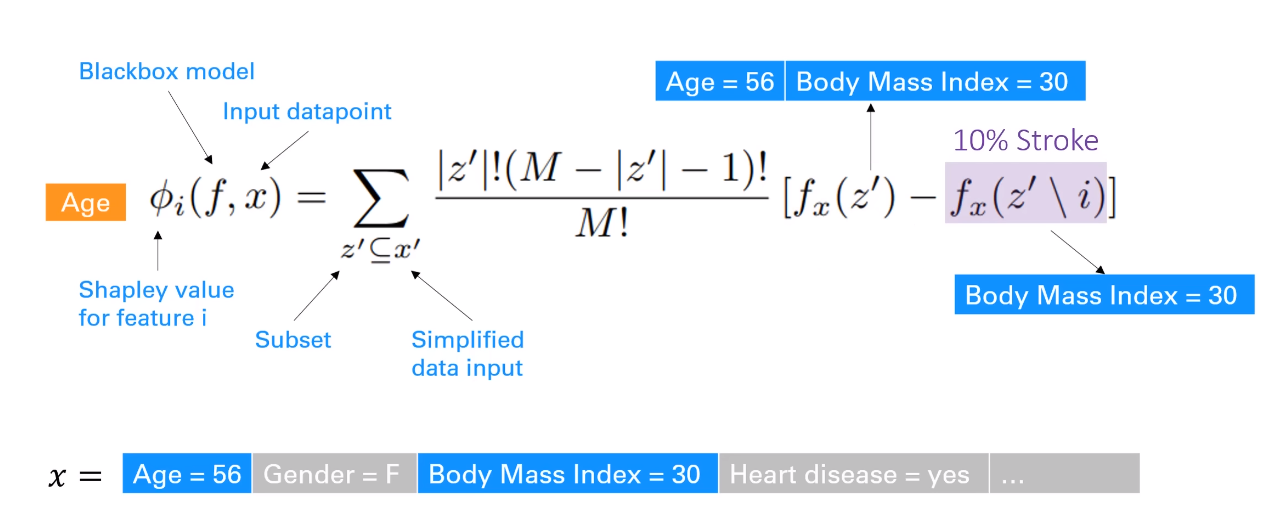

Important: when we say 'shapley value for feature i', we mean a specific value for feature i! Because this is a local explanation method, the shapley value for feature i can be different for different examples. It is not a global importance score, but rather a specific contribution of that feature to the prediction for that particular example.

## Implementation Challenges

### 1. The "Missing Feature" Problem
Machine learning models usually require fixed-size inputs. You cannot simply "remove" a feature because the model's mathematical shape would break. 
* **The Solution:** For features we want to exclude, we input **random values from a background/training dataset**. This "samples out" the feature's relevance, rendering it effectively random and without predictive power.

### 2. Computational Complexity
Calculating all permutations is **exponentially expensive** ($2^n$). For a model with many features, calculating the exact average contribution is computationally impossible.

---

## Kernel SHAP: The Approximation

**Those issues can be sidestepped by learning a _local linear approximator_.** Instead of calculating every combination, Kernel SHAP samples the feature space and fits a weighted linear model where the coefficients act as the Shapley values.

**The Process:**
1.  **Sample Vectors:** Sample multiple simplified vectors $z^\prime \in \{0, 1\}^{n}$ where $1$ means the feature is present and $0$ means it is absent.
2.  **Construct Examples:** * If $z_j^\prime = 1$, we set $x^\prime_j = x_j$ (the actual value).
    * If $z_j^\prime = 0$, we sample $x^\prime_j$ from a **background set**.
3.  **Weighted Linear Model:** Train a particular type of linear model on these examples, weighting samples based on the information they provide about the Shapley values.
4.  **Result:** The coefficients of this linear model are the **approximated Shapley values**.



While **Kernel SHAP** is model-agnostic, other techniques like **TreeSHAP** (for trees) or **DeepSHAP** (for neural networks) use model internals to calculate these values more efficiently.

## Kernel SHAP

**The method we have just described is referred to as Kernel-SHAP**

It works even if we used _kernels_ computed on the original features

* E.g. we can group multiple features, or apply non-linear transformations
* In that case, the Shapely values will apply to the kernels

**Other approximation/computation methods have been defined**

* DeepSHAP for Deep NNs
* TreeSHAP for tree models
* ...

**Note:** beware of TreeShap, it is fast an exact, but it _relies on a slighly different semantic_! Be sure to understand the method you choose to use

## SHAP in Action

**The authors of the SHAP paper maintain [a nice Python package](https://github.com/shap/shap)**

...Which we are going to use to _explain_ our non-linear model

In [2]:
f = lambda x: xbm.predict_proba(x)[:,1]
explainer = shap.KernelExplainer(f, shap.sample(X_train, 100), link='logit')
shap_values = explainer(X_test)
with open(os.path.join('..', 'data', 'shap_values.pickle'), 'wb') as fp:
    pickle.dump(shap_values, fp)

100%|███████████████████████████████████████████████████████████████████| 100/100 [00:02<00:00, 48.82it/s]


* We'll focus on the _test_ data, since we want to find the true correlates
* For classifiers, it easier to explain _logits_ rather than probabilities
* The process can be slow, and using a small backgrond set is recommended
* The result contains the Shapely values, the base values, and the original data

## Waterfall Plots

**The SHAP library allows us to build _waterfall plots_**

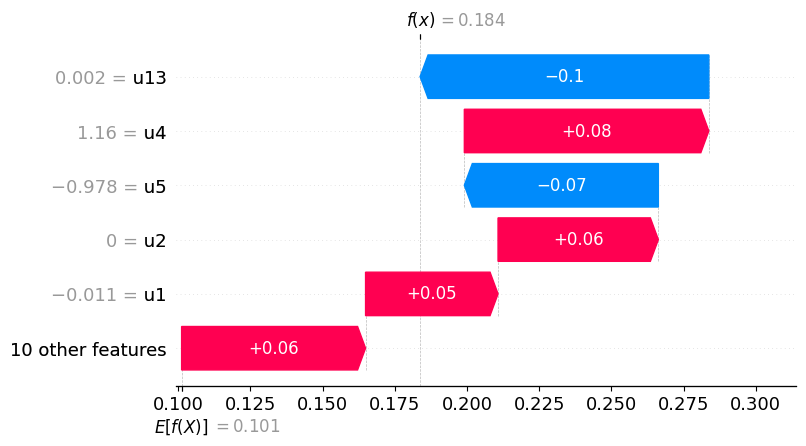

In [3]:
shap.plots.waterfall(shap_values[0], max_display=6)

* The bars represent the Shapely values, the colors their sign

## Force Plots

**Waterfall plots can be "compacted" into _force plots_**

Here we have again a plot for example 0:

In [4]:
shap.initjs()
shap.plots.force(shap_values[0])

...And have a plot for example 99

In [5]:
shap.plots.force(shap_values[99])

## Global Force Plots

**Force plots can be stacked to inspect many examples at once:**

In [6]:
shap.plots.force(shap_values)

## Scatter Plots

**We can use _scatter plots_ to show the effect of a single feature**

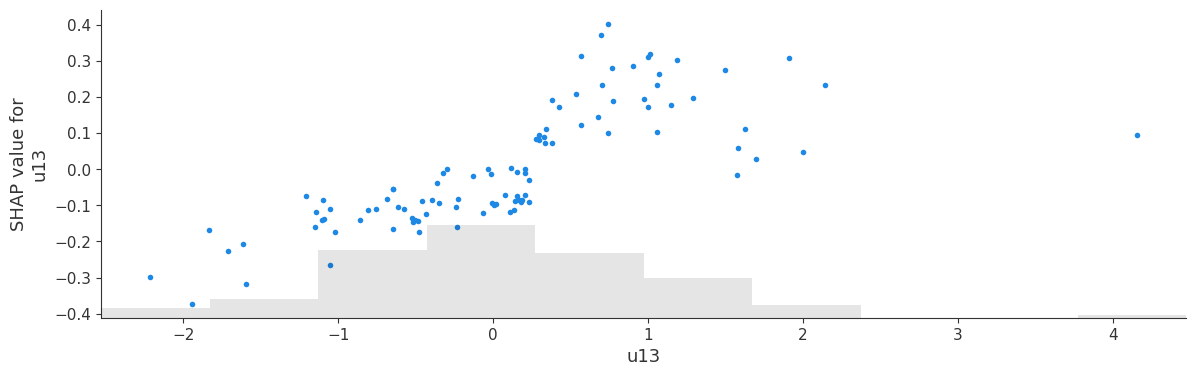

In [7]:
plt.figure(figsize=figsize)
shap.plots.scatter(shap_values[:, 'u13'], ax=plt.gca())

* The gray area is the histogram of the chosen feature

## Beeswarm (Summary) Plot

**We can stack (and color) multiple scatter plots to obtain a _beeswarm_ plot:**

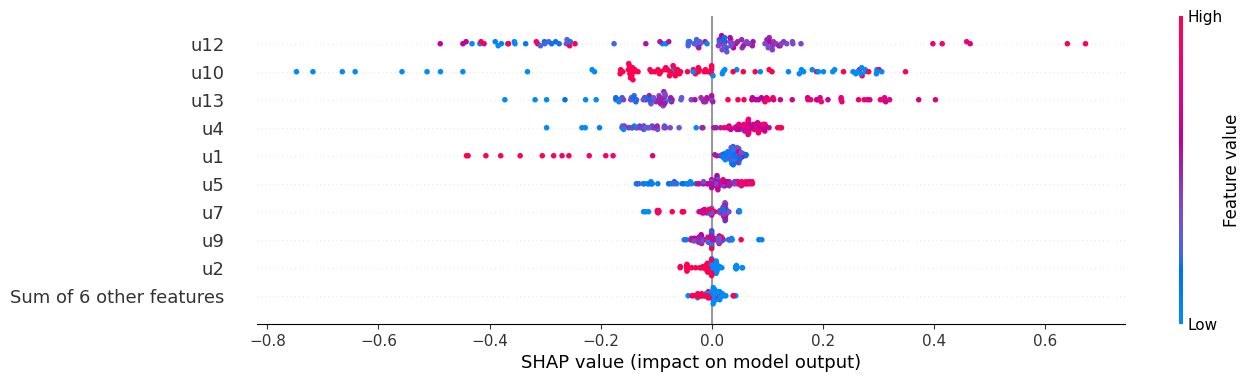

In [8]:
shap.plots.beeswarm(shap_values, max_display=10, plot_size=figsize)

* By checking the color distribution we can indentify (e.g.) monotonic effects

## Scatter (Dependency) Plots

**We can color scatter plots _by using another feature_ to highlight dependency**

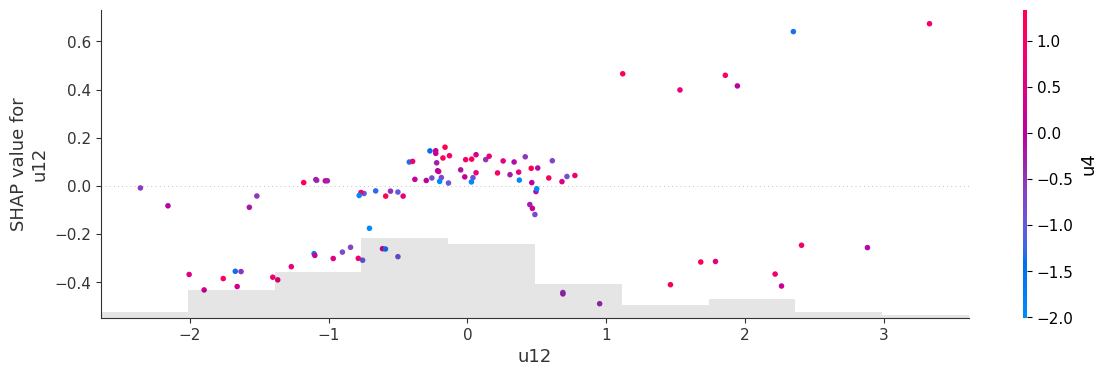

In [9]:
plt.figure(figsize=figsize)
shap.plots.scatter(shap_values[:, 'u12'], color=shap_values[:, 'u4'], ax=plt.gca())

* In this case we are coloring the "u12" values by using "u4"

## Scatter (Dependency) Plots

**We can let the library choose the best coloring feature**

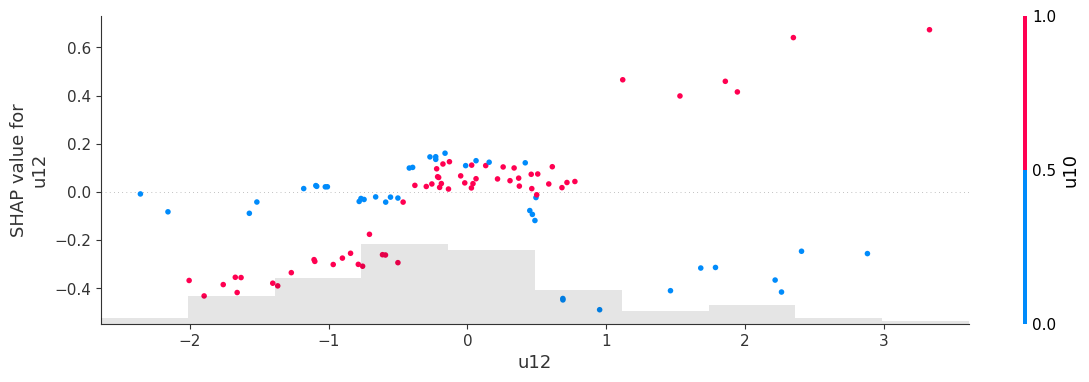

In [10]:
plt.figure(figsize=figsize)
shap.plots.scatter(shap_values[:, 'u12'], color=shap_values, ax=plt.gca())

* The chosen coloring feature changes how "u12" impacts the output in a noticeable way